In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


In [4]:
df = pd.read_csv(r"C:\Users\Trapa\OneDrive\Documents\Mall_Customers.csv")
print(df.head())
print(df.info())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [5]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]
print(X.head())

   Age  Annual Income (k$)  Spending Score (1-100)
0   19                  15                      39
1   21                  15                      81
2   20                  16                       6
3   23                  16                      77
4   31                  17                      40


In [6]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X)
print(df["Cluster"].value_counts())

Cluster
0    124
1     41
2     35
Name: count, dtype: int64


C:\Users\Trapa\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


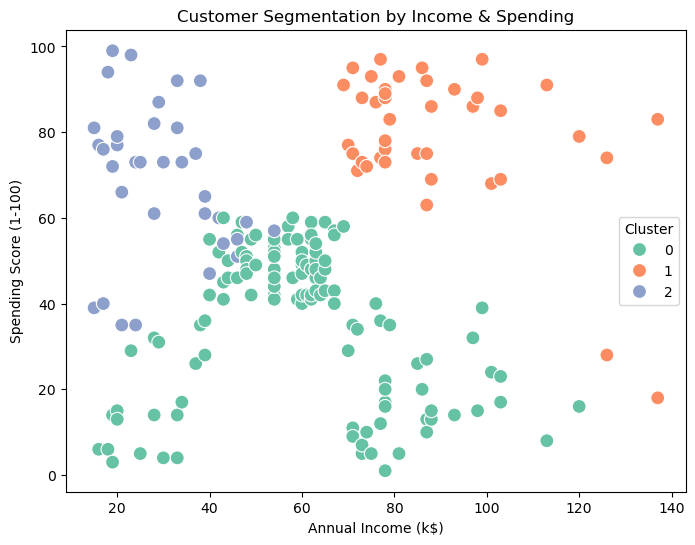

In [7]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)",  hue="Cluster", data=df, palette="Set2", s=100)
plt.title("Customer Segmentation by Income & Spending")
plt.show()

In [8]:
labels = {0:"Low Spenders", 1:"Medium Spenders", 2:"High Spenders"}
df["Segment"] = df["Cluster"].map(labels)
print(df[["Age", "Annual Income (k$)", "Spending Score (1-100)", "Segment"]].head())

   Age  Annual Income (k$)  Spending Score (1-100)        Segment
0   19                  15                      39  High Spenders
1   21                  15                      81  High Spenders
2   20                  16                       6   Low Spenders
3   23                  16                      77  High Spenders
4   31                  17                      40  High Spenders


DOCUMENTATION

1. Introduction
Problem: Businesses need to understand customer behavior.
Goal: Segment mall customers into groups based on spending habits.

2. Dataset
Source: Kaggle – Mall Customers Dataset.
Features used: Age, Annual Income, Spending Score.

3. Methodology
Applied K-Means clustering (unsupervised learning).
Chose 3 clusters for simplicity.
Visualized clusters using Income vs Spending Score.

4. Results
Cluster 0 → Low Spenders
Cluster 1 → Medium Spenders
Cluster 2 → High Spenders
Clear separation visible in scatter plot.

5. Business Insights
Low spenders → Target with promotions.
Medium spenders → Encourage loyalty programs.
High spenders → Premium services & personalized offers.

6. Conclusion
K-Means clustering successfully grouped customers.
Provides actionable insights for marketing strategy.